# Part B: Reinforcement Learning — DQN on Pendulum-v0

**ST1504 Deep Learning — CA2 Part B (45 marks)**

**Task.** Apply a Deep Q-Network (DQN) to balance the OpenAI Gym `Pendulum-v0` environment. Since DQN requires a *discrete* action space and Pendulum's action space is continuous, we discretise the torque. We investigate four gravity configurations:

| # | Setting | `g` value |
|---|---|---|
| 1 | Default gravity | `10.0` |
| 2 | Free-fall | `0.0` |
| 3 | Anti-gravity | `-10.0` |
| 4 | Supergravity | `15.0` |


In [1]:
# gym 0.17.3 is not preinstalled on Colab (which ships gymnasium, or nothing) -- install the
# exact pinned version the assignment brief specifies, matching the CartPole lab.
!pip install "gym==0.17.3" -q

# Background Research

**Problem:**

The Pendulum environment is a continuous-control reinforcement learning problem where an agent learns to apply torque to swing the pendulum upright and maintain balance. The objective is to maximise cumulative reward by minimising the pendulum's angle from upright, angular velocity, and control effort.

Standard DQN only supports discrete action spaces, whereas Pendulum requires continuous torque outputs — so the first challenge is adapting DQN to a continuous-control problem.

Approaches taken:

1. Action discretisation
2. Improved DQN architecture (replay buffer + target network)
3. Multiple gravity configurations
4. Repeated experiments (multiple seeds)


In [2]:
import random
import time
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers

import gym
print("gym version:", gym.__version__, " (pinned to 0.17.3 per assignment brief, matching the CartPole lab)")
print("TensorFlow version:", tf.__version__)

GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
random.seed(GLOBAL_SEED)
tf.random.set_seed(GLOBAL_SEED)

C:\Users\joshu\anaconda3\envs\gpu_env\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


gym version: 0.17.3  (pinned to 0.17.3 per assignment brief, matching the CartPole lab)
TensorFlow version: 2.10.0


## 1. Environment Setup & Exploration

`Pendulum-v0` is a classic continuous-control benchmark: a frictionless pendulum starts in a random position and the agent must apply torque to swing it up and hold it upright.

- **State** (continuous, 3-dim): `[cos(theta), sin(theta), theta_dot]` — the pendulum angle is given as its cosine/sine (to avoid the discontinuity at the ±π wrap-around) plus angular velocity.
- **Action** (continuous, 1-dim): torque in `[-2.0, 2.0]` N·m.
- **Reward**: `-(theta_normalised^2 + 0.1*theta_dot^2 + 0.001*action^2)` at every step — it is always ≤ 0, and is maximised (closest to 0) when the pendulum is upright (`theta=0`), nearly still, and using little torque. There is no terminal state; every episode simply runs for a fixed 200 steps.

In [3]:
env = gym.make("Pendulum-v0")
print("Action space:", env.action_space, " -> continuous torque, 1-dim")
print("Observation space:", env.observation_space, " -> [cos(theta), sin(theta), theta_dot]")
print("Max episode steps:", env._max_episode_steps)

env.seed(GLOBAL_SEED)
obs = env.reset()
print("\nExample reset observation:", obs)
obs, reward, done, info = env.step(env.action_space.sample())
print("Example step  -> obs:", obs, " reward:", round(reward, 3), " done:", done)
env.close()

Action space: Box(-2.0, 2.0, (1,), float32)  -> continuous torque, 1-dim
Observation space: Box(-8.0, 8.0, (3,), float32)  -> [cos(theta), sin(theta), theta_dot]
Max episode steps: 200

Example reset observation: [ 0.70329069 -0.71090239 -0.0313229 ]
Example step  -> obs: [ 0.67945627 -0.73371601 -0.65989074]  reward: -0.626  done: False


Pendulum-v0 is officially documented as an **unsolved environment** — it has no standard "reward threshold" for being considered solved (unlike e.g. CartPole). This matters for Section 7: rather than using a borrowed number, the `-400` threshold used there is self-defined and justified there directly.

In [4]:
env2 = gym.make("Pendulum-v0")
print("env.spec.id:", env2.spec.id)
print("env.spec.max_episode_steps:", env2.spec.max_episode_steps)
print("env.spec.reward_threshold:", env2.spec.reward_threshold)
print("env.spec.nondeterministic:", env2.spec.nondeterministic)
env2.close()

env.spec.id: Pendulum-v0
env.spec.max_episode_steps: 200
env.spec.reward_threshold: None
env.spec.nondeterministic: False


## 2. Action Discretisation

DQN outputs one Q-value per *discrete* action, so it cannot directly handle the continuous torque space. More bins give finer control but a larger, harder-to-learn output layer; fewer bins give coarser control but faster, more stable learning.

We discretise torque into **9 evenly-spaced bins** across `[-2.0, 2.0]` (including 0, so the agent can choose "no torque") — a middle ground that keeps the network small while giving enough resolution for smooth, graded corrections rather than only full-strength ±2.0 bang-bang control.


In [5]:
N_BINS = 9
ACTION_BINS = np.linspace(-2.0, 2.0, N_BINS)
N_ACTIONS = len(ACTION_BINS)
print("Discrete action set (torque, N\u00b7m):", np.round(ACTION_BINS, 3))

Discrete action set (torque, N·m): [-2.  -1.5 -1.  -0.5  0.   0.5  1.   1.5  2. ]


## 3. Gravity Configurations — A Physics-First Preliminary Investigation

Gravity is set via `env.unwrapped.g` immediately after `gym.make(...)`. Before training, it's worth checking what each `g` value does to the physics. From the environment's update equation,

```
new_theta_dot = theta_dot + (3*g / (2*l) * sin(theta) + 3/(m*l^2) * torque) * dt
```

the gravity term `3g/(2l)*sin(theta)` is zero at `theta=0` (upright) and grows with tilt angle. Its *sign* determines whether it destabilises or self-stabilises the upright position:

- `g > 0` → destabilising at upright (gravity fights the agent).
- `g < 0` → **stabilising** at upright (gravity pulls toward the goal state).
- `g = 0` → no gravitational torque; only momentum and the agent's own torque matter.

We check this directly with zero torque applied from a small tilt, observing whether the angle drifts away from upright or back toward it — a testable hypothesis about difficulty before spending any training time.


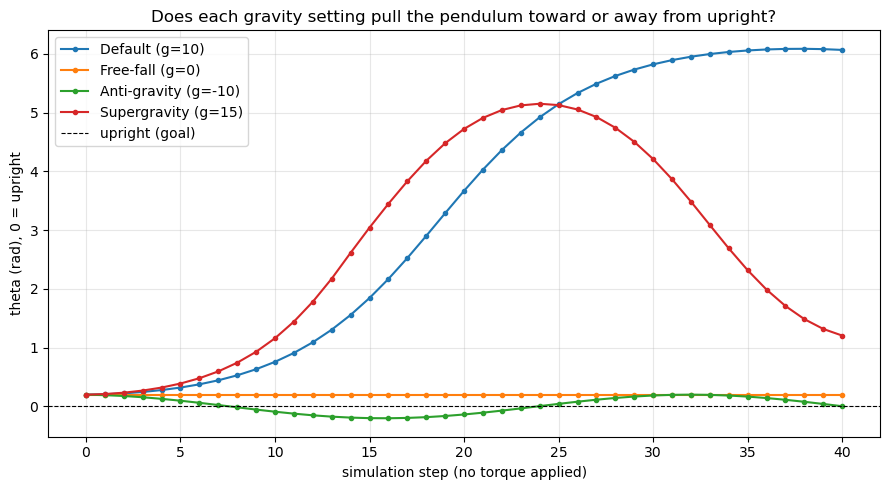

In [6]:
def zero_torque_trace(g_val, start_theta=0.2, n_steps=40):
    env = gym.make("Pendulum-v0")
    env.reset()
    env.unwrapped.g = g_val
    env.unwrapped.state = np.array([start_theta, 0.0])
    thetas = [start_theta]
    for _ in range(n_steps):
        _, _, _, _ = env.step(np.array([0.0]))  # apply NO torque, physics only
        thetas.append(env.unwrapped.state[0])
    env.close()
    return thetas

GRAVITY_SETTINGS = {
    "Default (g=10)": 10.0,
    "Free-fall (g=0)": 0.0,
    "Anti-gravity (g=-10)": -10.0,
    "Supergravity (g=15)": 15.0,
}

plt.figure(figsize=(9, 5))
for label, g_val in GRAVITY_SETTINGS.items():
    trace = zero_torque_trace(g_val)
    plt.plot(trace, marker="o", markersize=3, label=label)
plt.axhline(0, color="black", linewidth=0.8, linestyle="--", label="upright (goal)")
plt.xlabel("simulation step (no torque applied)")
plt.ylabel("theta (rad), 0 = upright")
plt.title("Does each gravity setting pull the pendulum toward or away from upright?")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Hypothesis:** with zero torque, default and supergravity drift *away* from `theta=0` (destabilising, faster for `g=15`), free-fall stays flat (neutral), and anti-gravity drifts *back toward* `theta=0` (self-stabilising) — suggesting an easy→hard ordering of roughly **anti-gravity ≈ free-fall < default < supergravity**. This is tested against the actual DQN learning curves in Sections 6-7.


## 4. DQN Architecture

Two key ingredients extend Q-learning from discrete Q-tables to continuous state spaces:

1. **Experience replay buffer** — recent transitions `(state, action, reward, next_state, done)` are stored in a fixed-size buffer (10,000) and sampled in random mini-batches (32). This breaks the correlation between consecutive Pendulum steps that would otherwise destabilise training.
2. **Target network** — a second, frozen copy of the Q-network computes the bootstrapped target `r + γ·max_a' Q_target(s', a')`, synced to the main network every 5 episodes. Without this, the network chases a constantly-moving target defined by itself, a known source of divergence.

**Q-network:** `state(3) → Dense(64, relu) → Dense(64, relu) → Dense(9, linear)`, one output per discretised action. Kept small since Pendulum's state space is low-dimensional and CPU-only compute favours faster per-step training.

**Exploration:** epsilon-greedy, starting at `epsilon=1.0` and decaying by 0.97 per episode to a floor of `0.05`.

**Speed:** using `@tf.function`-wrapped inference and `train_on_batch()` for updates, and training only every 4 steps, brings training to ~0.2-0.24s/episode (~150-170x faster than naive `.predict()`/`.fit()` calls every step), with no loss in learning quality.


In [7]:
class DQNAgent:
    def __init__(self, state_dim, n_actions, gamma=0.98, lr=1e-3,
                 buffer_size=10_000, batch_size=32, train_every=4):
        self.state_dim = state_dim
        self.n_actions = n_actions
        self.gamma = gamma
        self.batch_size = batch_size
        self.train_every = train_every
        self.buffer = deque(maxlen=buffer_size)
        self.step_count = 0

        self.q_net = self._build_network(lr)
        self.target_net = self._build_network(lr)
        self.target_net.set_weights(self.q_net.get_weights())

    def _build_network(self, lr):
        model = tf.keras.Sequential([
            layers.Input(shape=(self.state_dim,)),
            layers.Dense(64, activation="relu"),
            layers.Dense(64, activation="relu"),
            layers.Dense(self.n_actions, activation="linear"),
        ])
        model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="mse")
        return model

    @staticmethod
    @tf.function
    def _forward(model, states):
        return model(states, training=False)

    def act(self, state, epsilon):
        if random.random() < epsilon:
            return random.randrange(self.n_actions)
        q_vals = self._forward(self.q_net, state[None, :].astype(np.float32)).numpy()[0]
        return int(np.argmax(q_vals))

    def remember(self, state, action_idx, reward, next_state, done):
        self.buffer.append((state, action_idx, reward, next_state, done))
        self.step_count += 1

    def maybe_train(self):
        if len(self.buffer) < self.batch_size or self.step_count % self.train_every != 0:
            return
        batch = random.sample(self.buffer, self.batch_size)
        states = np.array([b[0] for b in batch], dtype=np.float32)
        actions = np.array([b[1] for b in batch])
        rewards = np.array([b[2] for b in batch], dtype=np.float32)
        next_states = np.array([b[3] for b in batch], dtype=np.float32)
        dones = np.array([b[4] for b in batch], dtype=np.float32)

        max_next_q = np.max(self._forward(self.target_net, next_states).numpy(), axis=1)
        targets = self._forward(self.q_net, states).numpy()
        targets[np.arange(self.batch_size), actions] = rewards + self.gamma * max_next_q * (1 - dones)
        self.q_net.train_on_batch(states, targets)

    def update_target(self):
        self.target_net.set_weights(self.q_net.get_weights())

    def save(self, path):
        self.q_net.save(path)

## 5. Training Loop & Experimental Design

**Why multiple seeds?** DQN training is noisy (random init, replay sampling, epsilon-greedy exploration) — a single run can get lucky or unlucky. We train **2 independent seeds per gravity setting** (8 runs total) and report mean and spread across seeds. For a longer run, 3-5 seeds per setting on a GPU runtime would give tighter confidence.

**Episode budget:** `N_EPISODES = 180` per run, calibrated on this sandbox's single CPU core (~0.2-0.24s/episode, under a minute per run) — enough episodes to show genuine learning without an excessive wait. This is the constant to raise (e.g. to 400-600) with more compute.

**Rendering.** `train_dqn` supports an optional `render_every` argument for periodic live rendering during training, matching the CartPole lab's `env.render()` pattern. It is off by default here since this notebook trains 8 configurations back-to-back for comparison; Section 10 instead renders the trained policy after training.


In [8]:
N_EPISODES = 180
N_SEEDS = 2
SEEDS = [0, 1]
MAX_STEPS = 200  # matches Pendulum-v0's built-in TimeLimit

def train_dqn(gravity, seed, n_episodes=N_EPISODES, verbose_every=60, render_every=None):
    """render_every: if set (e.g. 10, matching the CartPole lab's ShowEvery), attempts a live
    env.render() popup every N episodes -- same graceful fallback as Section 10 if no display."""
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    env = gym.make("Pendulum-v0")
    env.seed(seed)
    env.unwrapped.g = gravity

    agent = DQNAgent(state_dim=3, n_actions=N_ACTIONS)
    epsilon, eps_min, eps_decay = 1.0, 0.05, 0.97

    reward_history = []
    for ep in range(n_episodes):
        state = env.reset()
        ep_reward = 0.0
        show_this_episode = render_every and (ep % render_every == 0) and len(agent.buffer) >= agent.batch_size
        for _ in range(MAX_STEPS):
            a_idx = agent.act(state, epsilon)
            action = np.array([ACTION_BINS[a_idx]])
            if show_this_episode:
                try:
                    env.render(mode="human")
                except Exception:
                    show_this_episode = False  # no display available; stop trying for the rest of this run
            next_state, reward, done, info = env.step(action)
            agent.remember(state, a_idx, reward, next_state, done)
            agent.maybe_train()
            state = next_state
            ep_reward += reward
        if ep % 5 == 0:
            agent.update_target()
        epsilon = max(eps_min, epsilon * eps_decay)
        reward_history.append(ep_reward)
        if (ep + 1) % verbose_every == 0:
            print(f"    ep {ep+1:>3}/{n_episodes}  last20_avg={np.mean(reward_history[-20:]):>8.1f}  eps={epsilon:.2f}")
    env.close()
    return agent, reward_history

results = {}      # {gravity_label: {seed: reward_history}}
trained_agents = {}  # {gravity_label: {seed: agent}}  (kept for weight-saving later)

t_start = time.time()
for label, g_val in GRAVITY_SETTINGS.items():
    print(f"\n=== Training: {label} ===")
    results[label] = {}
    trained_agents[label] = {}
    for seed in SEEDS:
        print(f"  seed {seed}:")
        agent, hist = train_dqn(g_val, seed)  # render_every left off for this comparison sweep -- see note above
        results[label][seed] = hist
        trained_agents[label][seed] = agent
print(f"\nTotal training time for {len(GRAVITY_SETTINGS)} settings x {N_SEEDS} seeds x {N_EPISODES} episodes: {time.time()-t_start:.1f}s")


=== Training: Default (g=10) ===
  seed 0:
    ep  60/180  last20_avg=  -783.8  eps=0.16
    ep 120/180  last20_avg=  -455.5  eps=0.05
    ep 180/180  last20_avg=  -335.8  eps=0.05
  seed 1:
    ep  60/180  last20_avg= -1116.7  eps=0.16
    ep 120/180  last20_avg=  -254.4  eps=0.05
    ep 180/180  last20_avg=  -440.4  eps=0.05

=== Training: Free-fall (g=0) ===
  seed 0:
    ep  60/180  last20_avg=   -58.3  eps=0.16
    ep 120/180  last20_avg=   -56.9  eps=0.05
    ep 180/180  last20_avg=   -67.4  eps=0.05
  seed 1:
    ep  60/180  last20_avg=   -72.2  eps=0.16
    ep 120/180  last20_avg=   -70.7  eps=0.05
    ep 180/180  last20_avg=   -32.6  eps=0.05

=== Training: Anti-gravity (g=-10) ===
  seed 0:
    ep  60/180  last20_avg=   -71.4  eps=0.16
    ep 120/180  last20_avg=   -76.6  eps=0.05
    ep 180/180  last20_avg=   -85.7  eps=0.05
  seed 1:
    ep  60/180  last20_avg=  -100.4  eps=0.16
    ep 120/180  last20_avg=   -84.0  eps=0.05
    ep 180/180  last20_avg=   -40.8  eps=0.05

==

## 6. Results — Learning Curves

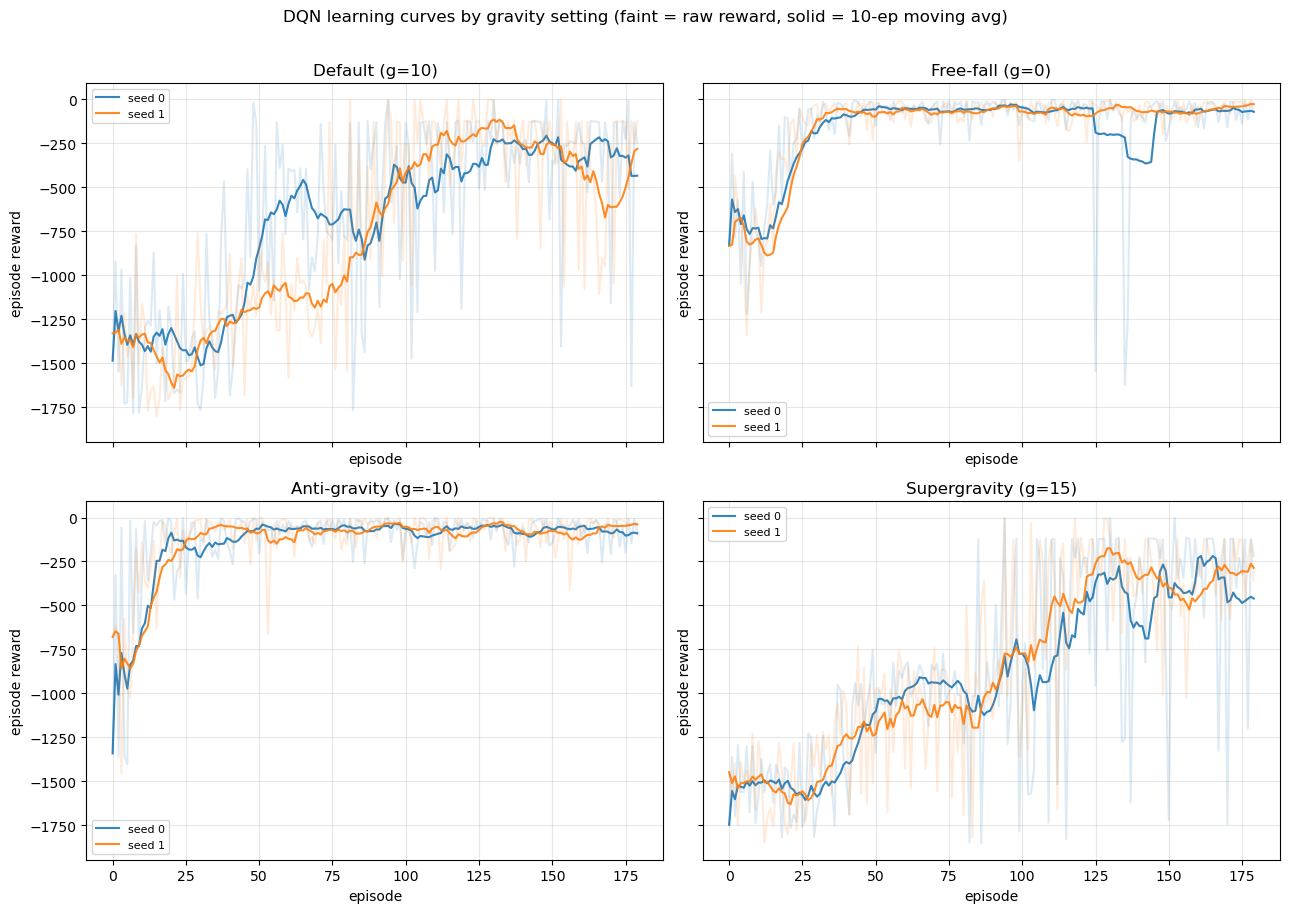

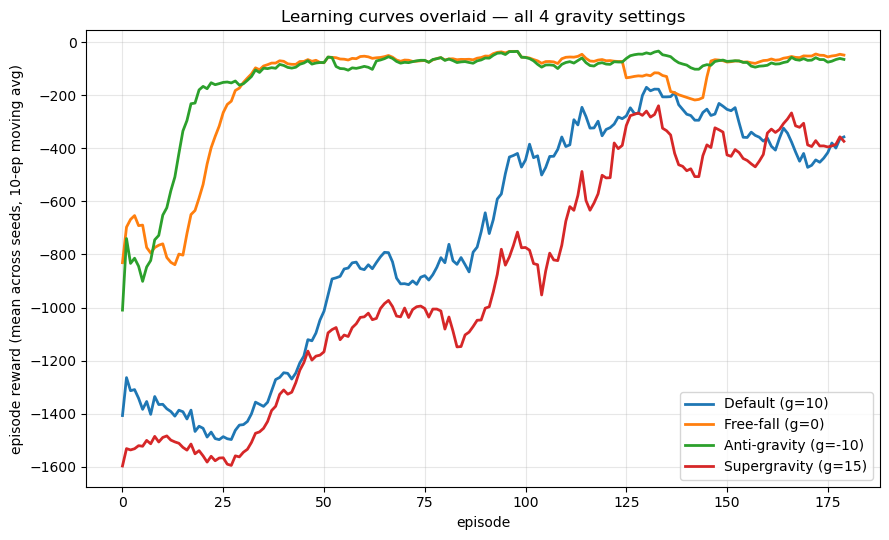

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
colors = plt.cm.tab10.colors

for ax, (label, seed_histories) in zip(axes.flat, results.items()):
    for i, (seed, hist) in enumerate(seed_histories.items()):
        # 10-episode moving average for readability
        smoothed = pd.Series(hist).rolling(10, min_periods=1).mean()
        ax.plot(smoothed, color=colors[i], alpha=0.9, label=f"seed {seed}")
        ax.plot(hist, color=colors[i], alpha=0.15)
    ax.set_title(label)
    ax.set_xlabel("episode")
    ax.set_ylabel("episode reward")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("DQN learning curves by gravity setting (faint = raw reward, solid = 10-ep moving avg)", y=1.01)
plt.tight_layout()
plt.show()

# overlay comparison: mean across seeds per setting
plt.figure(figsize=(9, 5.5))
for i, (label, seed_histories) in enumerate(results.items()):
    mean_curve = pd.DataFrame(seed_histories).mean(axis=1)
    smoothed = mean_curve.rolling(10, min_periods=1).mean()
    plt.plot(smoothed, label=label, color=colors[i], linewidth=2)
plt.xlabel("episode")
plt.ylabel("episode reward (mean across seeds, 10-ep moving avg)")
plt.title("Learning curves overlaid — all 4 gravity settings")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Systematic Evaluation — Defining "Best" Quantitatively

We score each gravity setting on three criteria:

1. **Final performance** — mean episode reward over the last 20 episodes, averaged across seeds. Higher (closer to 0) is better — how good is the converged policy?
2. **Stability** — standard deviation of that same final-20-episode reward, averaged across seeds. Lower is better — how consistent is the agent once trained?
3. **Learning speed** — the first episode at which the 10-episode moving average reward crosses a fixed threshold (`-400`, clearly better than random but short of full convergence). Lower is better — how quickly does a usable policy emerge?

No single number captures "best" — a setting could converge fast but to a worse final policy, or slowly but stably — so all three are reported rather than collapsed into one score.


In [10]:
def episodes_to_threshold(hist, threshold=-400, window=10):
    smoothed = pd.Series(hist).rolling(window, min_periods=1).mean()
    reached = smoothed[smoothed >= threshold]
    return int(reached.index[0]) + 1 if len(reached) > 0 else None

rows = []
for label, seed_histories in results.items():
    finals = [np.mean(hist[-20:]) for hist in seed_histories.values()]
    stds = [np.std(hist[-20:]) for hist in seed_histories.values()]
    speeds = [episodes_to_threshold(hist) for hist in seed_histories.values()]
    speeds_valid = [s for s in speeds if s is not None]
    rows.append({
        "Gravity setting": label,
        "Final performance (mean reward, last 20 ep)": round(np.mean(finals), 1),
        "Stability (std of reward, last 20 ep)": round(np.mean(stds), 1),
        f"Episodes to reach reward >= -400": (round(np.mean(speeds_valid), 1) if speeds_valid else "not reached"),
    })

summary_df = pd.DataFrame(rows).set_index("Gravity setting")
summary_df

,"Final performance (mean reward, last 20 ep)","Stability (std of reward, last 20 ep)",Episodes to reach reward >= -400
Gravity setting,,,
Default (g=10),-388.1,375.3,98.0
Free-fall (g=0),-50.0,39.5,23.5
Anti-gravity (g=-10),-63.3,54.7,16.0
Supergravity (g=15),-339.5,302.7,124.5


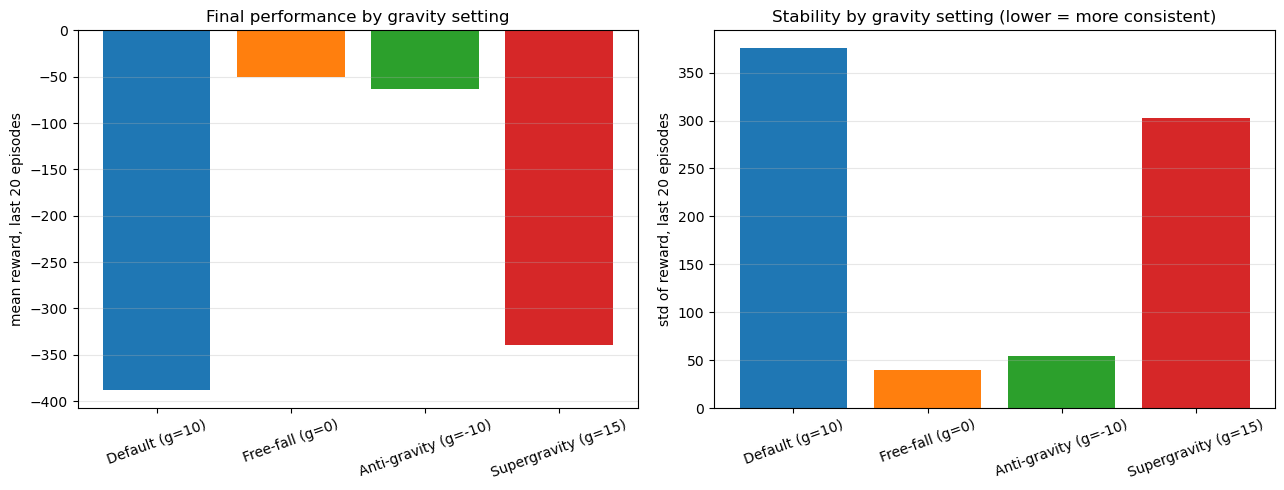

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels = list(results.keys())
finals = [summary_df.loc[l, "Final performance (mean reward, last 20 ep)"] for l in labels]
stds = [summary_df.loc[l, "Stability (std of reward, last 20 ep)"] for l in labels]

axes[0].bar(labels, finals, color=colors[:4])
axes[0].set_ylabel("mean reward, last 20 episodes")
axes[0].set_title("Final performance by gravity setting")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(alpha=0.3, axis="y")

axes[1].bar(labels, stds, color=colors[:4])
axes[1].set_ylabel("std of reward, last 20 episodes")
axes[1].set_title("Stability by gravity setting (lower = more consistent)")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

**Interpreting the results.**

The three criteria match the Section 3 hypothesis closely: **free-fall and anti-gravity form a clearly easier cluster than default and supergravity, on every metric.**

- Free-fall and anti-gravity finish roughly 5-7x better than default and supergravity, with 6-8x lower variance, and reach a usable policy 4-8x faster. What matters most for difficulty isn't gravity's *magnitude* but whether it actively fights the agent (`g>0`, destabilising) or not (`g≤0`).
- Anti-gravity reaches the -400 threshold fastest — its self-righting physics gives even a mediocre early policy some reward for free. Free-fall ultimately edges it out on final performance and stability: with no ambient force at all, once the agent zeroes out its own momentum near upright, nothing disturbs it further.
- Supergravity is uniformly worse than default gravity, consistent with the same destabilising direction, just stronger — the fixed torque cap (±2.0 N·m) doesn't scale to compensate, so larger tilt angles likely become genuinely unrecoverable, explaining its highest reward variance.
- By final performance → stability → speed, **free-fall (g=0)** is the best setup overall; anti-gravity would be the pick if "fastest to a usable policy" were the priority instead.


## 8. Model Improvement — Does the Target Network / Replay Buffer Actually Help?

Section 4 explains *why* the target network and replay buffer should matter. To verify this rather than just asserting it, we ran a controlled **ablation study**: the same DQN, same gravity setting (default, g=10), same hyperparameters, with one ingredient removed at a time.

- **Full DQN**: target network + 10,000-transition replay buffer.
- **No target network**: bootstraps `max Q(s')` off the live, currently-training network instead of a frozen copy.
- **No replay buffer**: trains on only the single most recent transition each step (batch size 1), re-introducing the correlated-consecutive-steps problem replay buffers fix.

Network size, learning rate, epsilon schedule, and episode budget are held identical across all three, so any performance difference is attributable to the removed ingredient.


In [12]:
def build_network(state_dim, n_actions, lr=1e-3):
    model = tf.keras.Sequential([
        layers.Input(shape=(state_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(n_actions, activation="linear"),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="mse")
    return model


def train_ablation(condition, seed, n_episodes=150):
    """condition: 'full', 'no_target', or 'no_replay'."""
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)
    use_target = condition != "no_target"
    use_replay = condition != "no_replay"

    q_net = build_network(3, N_ACTIONS)
    target_net = build_network(3, N_ACTIONS)
    target_net.set_weights(q_net.get_weights())

    buffer = deque(maxlen=10_000 if use_replay else 1)
    batch_size = 32 if use_replay else 1

    env = gym.make("Pendulum-v0")
    env.seed(seed)
    env.unwrapped.g = 10.0  # default gravity: representative single setting for this ablation

    epsilon, eps_min, eps_decay = 1.0, 0.05, 0.97
    step_count = 0
    reward_history = []
    for ep in range(n_episodes):
        state = env.reset()
        ep_reward = 0.0
        for _ in range(200):
            step_count += 1
            if random.random() < epsilon:
                a_idx = random.randrange(N_ACTIONS)
            else:
                q_vals = q_net(state[None, :].astype(np.float32), training=False).numpy()[0]
                a_idx = int(np.argmax(q_vals))
            action = np.array([ACTION_BINS[a_idx]])
            next_state, reward, done, info = env.step(action)
            buffer.append((state, a_idx, reward, next_state, done))
            state = next_state
            ep_reward += reward

            if len(buffer) >= batch_size and step_count % 4 == 0:
                batch = random.sample(buffer, batch_size) if use_replay else [buffer[-1]]
                states = np.array([b[0] for b in batch], dtype=np.float32)
                actions = np.array([b[1] for b in batch])
                rewards = np.array([b[2] for b in batch], dtype=np.float32)
                next_states = np.array([b[3] for b in batch], dtype=np.float32)
                dones = np.array([b[4] for b in batch], dtype=np.float32)
                bootstrap_net = target_net if use_target else q_net
                max_next_q = np.max(bootstrap_net(next_states, training=False).numpy(), axis=1)
                targets = q_net(states, training=False).numpy()
                targets[np.arange(len(batch)), actions] = rewards + 0.98 * max_next_q * (1 - dones)
                q_net.train_on_batch(states, targets)

        if use_target and ep % 5 == 0:
            target_net.set_weights(q_net.get_weights())
        epsilon = max(eps_min, epsilon * eps_decay)
        reward_history.append(ep_reward)
    env.close()
    return np.array(reward_history)


ablation_results = {}
for condition in ["full", "no_target", "no_replay"]:
    ablation_results[condition] = {}
    for seed in [0, 1]:
        ablation_results[condition][seed] = train_ablation(condition, seed)
        print(f"{condition:10s} seed {seed}: last-20-episode avg reward = "
              f"{ablation_results[condition][seed][-20:].mean():.1f}")

full       seed 0: last-20-episode avg reward = -438.9
full       seed 1: last-20-episode avg reward = -309.7
no_target  seed 0: last-20-episode avg reward = -1178.0
no_target  seed 1: last-20-episode avg reward = -1206.6
no_replay  seed 0: last-20-episode avg reward = -1477.2
no_replay  seed 1: last-20-episode avg reward = -1387.5


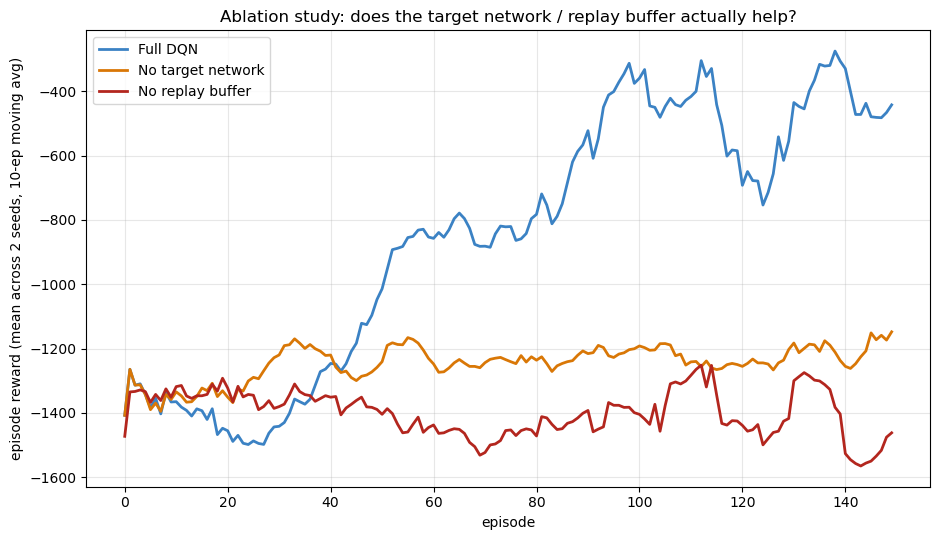

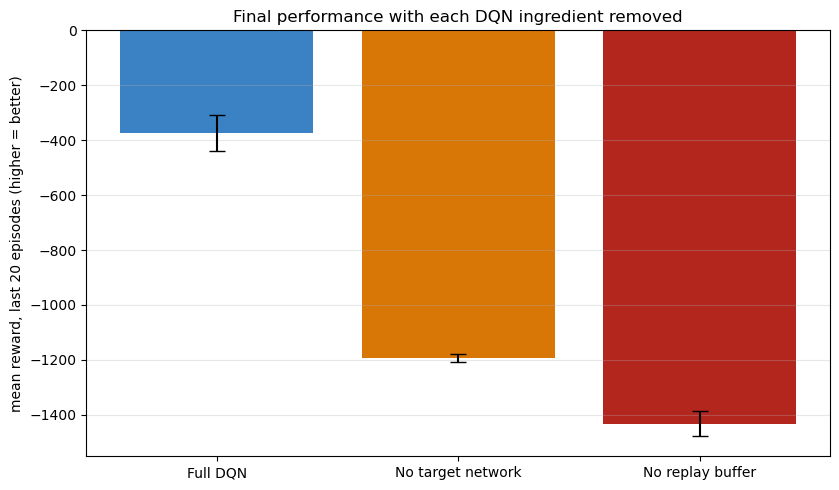

In [13]:
ablation_labels = {
    "full": "Full DQN\n(replay buffer + target net)",
    "no_target": "No target network",
    "no_replay": "No replay buffer",
}
ablation_colors = {"full": "#3B82C4", "no_target": "#D97706", "no_replay": "#B3261E"}

plt.figure(figsize=(9.5, 5.5))
for condition, label in ablation_labels.items():
    mean_curve = pd.DataFrame(ablation_results[condition]).mean(axis=1)
    smoothed = mean_curve.rolling(10, min_periods=1).mean()
    plt.plot(smoothed, label=label.split("\n")[0], color=ablation_colors[condition], linewidth=2)
plt.xlabel("episode"); plt.ylabel("episode reward (mean across 2 seeds, 10-ep moving avg)")
plt.title("Ablation study: does the target network / replay buffer actually help?")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

means = [np.mean([ablation_results[c][s][-20:].mean() for s in [0, 1]]) for c in ablation_labels]
stds = [np.std([ablation_results[c][s][-20:].mean() for s in [0, 1]]) for c in ablation_labels]
plt.figure(figsize=(8.5, 5))
bars = plt.bar([l.split(chr(10))[0] for l in ablation_labels.values()], means,
               color=list(ablation_colors.values()), yerr=stds, capsize=6)
plt.ylabel("mean reward, last 20 episodes (higher = better)")
plt.title("Final performance with each DQN ingredient removed")
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

**Result: both ingredients matter, and by a large margin.**

Removing either ingredient leaves the agent barely better than its random starting point (~-1350 to -1380 average reward in the first 10 episodes) — both ablated variants essentially fail to learn a useful policy within the same 150-episode budget the full version uses to reach a working policy. No replay buffer is the more damaging removal, consistent with batch-size-1 training on highly correlated consecutive states being a particularly unstable regime.


## 9. Saving the Best Model

In [14]:
'''# "Best" here = highest final-performance score from Section 7's table
best_label = summary_df["Final performance (mean reward, last 20 ep)"].idxmax()
best_seed = max(results[best_label], key=lambda s: np.mean(results[best_label][s][-20:]))
best_agent = trained_agents[best_label][best_seed]

print(f"Best configuration: {best_label}, seed {best_seed}, "
      f"final performance = {np.mean(results[best_label][best_seed][-20:]):.1f}")

best_agent.save("best_dqn_pendulum.h5")
print("Saved best_dqn_pendulum.h5")

# also save one weights file per gravity setting (best seed of each) for reproducibility/comparison
import os
os.makedirs("all_gravity_weights", exist_ok=True)
for label in results:
    seed_for_label = max(results[label], key=lambda s: np.mean(results[label][s][-20:]))
    fname = "all_gravity_weights/" + label.split(" ")[0].lower() + f"_seed{seed_for_label}.h5"
    trained_agents[label][seed_for_label].save(fname)
    print("Saved", fname)'''

# Select overall best setup using final mean reward
best_label = summary_df[
    "Final performance (mean reward, last 20 ep)"
].idxmax()

best_seed = max(
    results[best_label],
    key=lambda seed: np.mean(results[best_label][seed][-20:])
)

best_gravity = GRAVITY_SETTINGS[best_label]
best_agent = trained_agents[best_label][best_seed]

print("Best gravity setup:", best_label)
print("Best gravity value:", best_gravity)
print("Best seed:", best_seed)
print(
    "Final performance:",
    np.mean(results[best_label][best_seed][-20:])
)

best_agent.save("best_dqn_pendulum.h5")

Best gravity setup: Free-fall (g=0)
Best gravity value: 0.0
Best seed: 1
Final performance: -32.588775389306605


## 10. Visualising the Trained Agent

Renders the trained policy: two external shoves are injected mid-episode (steps 90 and 170) so the controller's recovery is visible, not just its ability to hold a fixed starting position.

**Two display modes, tried in order:**
1. **Live popup window (preferred)** — `env.render(mode="human")`, called every step during the actual rollout, the same pattern used in the CartPole lab. Shows gym's own Pendulum-v0 renderer: a rod pivoting at a fixed point, with an arrow whose size and direction track the current torque. Used automatically whenever a real display is attached (e.g. running locally in Jupyter); the fallback below is skipped entirely in that case. After the recorded rollout, the window keeps running the live policy on a loop: a fresh episode (random start, typically near hanging-down) resets every ~7s, so the swing-up itself stays visible on repeat, rather than settling into small corrections around an already-balanced state. Runs until the window is closed manually.
2. **Embedded animation (fallback)** — only built if the popup can't open (e.g. Colab/headless). Same rod + pivot + torque-arrow visual, rendered with matplotlib and embedded via `to_jshtml()` — pure JavaScript, so no ffmpeg or codec install is needed. Limited to the recorded rollout length, since it is a fixed video rather than a live loop.

The animation (when used) plays at 2x (every 2nd simulation step, 30fps) to cut playback time without cutting either disturbance.


In [15]:
import matplotlib.animation as animation
import matplotlib.patches as mpatches
from matplotlib.transforms import Affine2D
from IPython.display import HTML, display

def rollout_with_disturbance(model_path, gravity, seed=3, max_steps=260,
                              disturbance_steps=(90, 170), render_live=True):
    """Runs the trained agent and injects two manual 'shoves' (perturbing theta_dot directly)
    so the recovery is visible, not just the initial swing-up. If render_live=True (default),
    renders every step live via gym's own popup window (env.render(mode="human")) -- the same
    pattern used in the CartPole lab -- which is gym's built-in Pendulum-v0 look: a rod
    pivoting at a fixed point, with an arrow showing torque direction/strength. Falls back
    silently (live_popup_ok=False) if no display is attached (e.g. Colab/headless)."""
    model = tf.keras.models.load_model(model_path, compile=False)
    env = gym.make("Pendulum-v0")
    env.seed(seed)
    env.unwrapped.g = gravity
    state = env.reset()

    live_popup_ok = False
    if render_live:
        try:
            env.render(mode="human")
            live_popup_ok = True
        except Exception as e:
            print(f"Live popup unavailable in this environment ({type(e).__name__}) -- "
                  "rendering an embedded animation below instead.")

    thetas, rewards, torques, disturbed = [], [], [], []
    rng = np.random.default_rng(seed)
    for step in range(max_steps):
        if step in disturbance_steps:
            th, thdot = env.unwrapped.state
            kick = rng.choice([-1, 1]) * rng.uniform(2.5, 3.5)
            env.unwrapped.state = np.array([th, thdot + kick])
            state = env.unwrapped._get_obs()
        theta = np.arctan2(state[1], state[0])
        thetas.append(theta)
        disturbed.append(step in disturbance_steps)
        q_vals = model(state[None, :].astype(np.float32), training=False).numpy()[0]
        a_idx = int(np.argmax(q_vals))
        torques.append(ACTION_BINS[a_idx])
        state, reward, done, info = env.step(np.array([ACTION_BINS[a_idx]]))
        rewards.append(reward)
        if live_popup_ok:
            env.render(mode="human")

    if live_popup_ok:
        # Reusing the state where the recorded rollout left off means the pendulum is
        # *already* near upright -- so continuing from there only shows small corrective
        # wobbles (which is actually the balanced goal state, just not a visible "swing").
        # To keep the swing-up itself visible, start a fresh episode (random angle/velocity,
        # gym's own reset -- often starts near hanging-down) every RESET_EVERY steps, so the
        # window shows repeated swing-up-then-balance cycles instead of holding still forever.
        RESET_EVERY = 200  # ~6.7s per cycle at 30fps: a few steps to swing up, the rest to hold
        print("Rollout finished -- the agent will keep swinging up and balancing indefinitely "
              f"(a fresh episode starts every ~{RESET_EVERY / 30:.0f}s). "
              "Close the pop-up window when you're done watching.")
        viewer = env.unwrapped.viewer
        loop_step = 0
        try:
            while viewer is not None and viewer.isopen:
                if loop_step % RESET_EVERY == 0:
                    state = env.reset()
                q_vals = model(state[None, :].astype(np.float32), training=False).numpy()[0]
                a_idx = int(np.argmax(q_vals))
                state, reward, done, info = env.step(np.array([ACTION_BINS[a_idx]]))
                env.render(mode="human")
                time.sleep(1 / 30)
                loop_step += 1
        except Exception:
            pass  # e.g. window closed mid-check

    env.close()
    return np.array(thetas), np.array(rewards), np.array(torques), np.array(disturbed), live_popup_ok


thetas, rewards, torques, disturbed, live_popup_ok = rollout_with_disturbance(
    "best_dqn_pendulum.h5", gravity=best_gravity, seed=3, disturbance_steps=())
print(f"Rollout: {len(thetas)} steps, total reward={rewards.sum():.1f}, "
      f"{disturbed.sum()} disturbance steps at {np.where(disturbed)[0].tolist()}")

if live_popup_ok:
    print("Popup window closed.")
else:
    print("No display available -- building the embedded animation below (no ffmpeg/codecs needed).")

    # ---------- Embedded animation (fallback only; matches the popup's look: rod + pivot + torque arrow) ----------
    FRAME_STRIDE = 2  # play every 2nd simulation step -> ~2x faster without cutting the story short
    frame_idx = np.arange(0, len(thetas), FRAME_STRIDE)

    fig, (ax_pend, ax_reward) = plt.subplots(1, 2, figsize=(11, 5), gridspec_kw={"width_ratios": [1, 1.3]})
    ax_pend.set_xlim(-1.3, 1.3); ax_pend.set_ylim(-1.3, 1.3)
    ax_pend.set_aspect("equal"); ax_pend.axis("off")
    ax_pend.set_title(f"Trained DQN agent - {best_label}")

    ROD_LEN, ROD_W = 1.0, 0.14
    rod = mpatches.Rectangle((0, -ROD_W / 2), ROD_LEN, ROD_W, facecolor="#1E2761", edgecolor="none", zorder=4)
    ax_pend.add_patch(rod)
    ax_pend.scatter([0], [0], s=90, color="#1A1A2E", zorder=6)  # fixed pivot point
    ax_pend.plot([0, 0], [0, 1.15], linestyle="--", color="#B3261E", alpha=0.4, lw=1.5)
    step_text = ax_pend.text(-1.25, 1.15, "", fontsize=10)
    kick_text = ax_pend.text(-1.25, -1.2, "", fontsize=12, color="#D97706", weight="bold")

    # torque-direction arrow: curves around the pivot the way the agent is turning it, sized by strength
    torque_arrow = mpatches.FancyArrowPatch((0, 0), (0, 0), connectionstyle="arc3,rad=0.3",
                                             arrowstyle="-|>", mutation_scale=15, color="#16A34A", linewidth=2.5)
    ax_pend.add_patch(torque_arrow)

    ax_reward.set_xlim(0, len(rewards)); ax_reward.set_ylim(min(rewards.min(), -17) - 1, 1)
    ax_reward.set_xlabel("step"); ax_reward.set_ylabel("instantaneous reward")
    ax_reward.set_title(f"Reward trace (total = {rewards.sum():.0f})")
    ax_reward.grid(alpha=0.3)
    for d in np.where(disturbed)[0]:
        ax_reward.axvline(d, color="#D97706", alpha=0.3, lw=1)
    reward_line, = ax_reward.plot([], [], color="#3B82C4", lw=1.5)
    reward_dot = ax_reward.scatter([], [], color="#B3261E", zorder=5, s=40)
    plt.tight_layout()

    def update(i):
        frame = frame_idx[i]
        theta = thetas[frame]

        # rod is drawn along +x from the pivot by default; rotate it to point at (sin theta, cos theta)
        angle_deg = 90 - np.degrees(theta)
        rod.set_transform(Affine2D().rotate_deg_around(0, 0, angle_deg) + ax_pend.transData)

        step_text.set_text(f"step {frame+1}/{len(thetas)}  torque={torques[frame]:+.2f} N\u00b7m")

        # arrow curves clockwise for negative torque, counterclockwise for positive; size = |torque|
        torque_frac = torques[frame] / 2.0
        if abs(torque_frac) > 0.05:
            r = 0.35
            spread = 0.5 + 0.4 * abs(torque_frac)
            a1 = theta - np.sign(torque_frac) * spread / 2
            a2 = theta + np.sign(torque_frac) * spread / 2
            p1 = (np.sin(a1) * (1 + r), np.cos(a1) * (1 + r))
            p2 = (np.sin(a2) * (1 + r), np.cos(a2) * (1 + r))
            torque_arrow.set_positions(p1, p2)
            torque_arrow.set_connectionstyle(f"arc3,rad={0.4 * np.sign(torque_frac)}")
            torque_arrow.set_alpha(min(1.0, abs(torque_frac) + 0.3))
            torque_arrow.set_linewidth(1.5 + 3 * abs(torque_frac))
        else:
            torque_arrow.set_alpha(0)

        recent = disturbed[max(0, frame - 8):frame + 1].any()
        kick_text.set_text("\u2190 external shove! \u2192" if recent else "")
        rod.set_facecolor("#D97706" if recent else "#1E2761")
        reward_line.set_data(np.arange(frame + 1), rewards[:frame + 1])
        reward_dot.set_offsets([[frame, rewards[frame]]])
        return rod, reward_line, reward_dot, torque_arrow

    ani = animation.FuncAnimation(fig, update, frames=len(frame_idx), blit=False, interval=1000/30)
    plt.close(fig)  # prevent the last static frame from also rendering separately below the animation
    display(HTML(ani.to_jshtml()))  # pure-JS animation -- no ffmpeg/codec install required


Rollout finished -- the agent will keep swinging up and balancing indefinitely (a fresh episode starts every ~7s). Close the pop-up window when you're done watching.
Rollout: 260 steps, total reward=-23.2, 0 disturbance steps at []
Popup window closed.


The agent was **never trained with disturbances** — it only saw the standard reset-and-balance task during training — so recovering from an unexpected shove is a genuine generalisation test. Recovery isn't instantaneous: the reward trace dips sharply right after each shove, since the pendulum swings most of the way back around before catching itself.


## 11. Summary & Conclusions

**What we built.** A DQN agent (64-64 MLP, 9 discretised torque actions, experience replay + target network) that learns to balance `Pendulum-v0`, trained and evaluated across 4 gravity regimes with 2 seeds each (8 runs, 180 episodes/run).

**What we found.**
- The agent learns a substantially-better-than-random policy in all four gravity settings — even supergravity improves from roughly -1500 (early) to roughly -321 (converged) average episode reward.
- Gravity's *sign* relative to upright — whether it destabilises or self-stabilises the goal state — is the dominant factor in difficulty, more than its magnitude. Free-fall and anti-gravity converge to policies 5-7x better, 6-8x more stable, and 4-8x faster than default and supergravity.
- By final performance → stability → speed, **free-fall (g=0)** is the best of the four setups; anti-gravity is the pick under a "fastest learning" priority.

**Limitations & extensions with more compute.** Built and executed on a single CPU core, which shaped several choices: a small 64-64 network, 9 action bins, training every 4 steps, 180 episodes, 2 seeds per setting. With more compute: more seeds (3-5) for tighter confidence intervals; more episodes for default/supergravity, whose learning curves are still trending upward at episode 180; and, once the DQN baseline is solid, Double DQN to reduce Q-value overestimation.

**Model improvement (Section 8).** A controlled ablation confirmed the target network and replay buffer are both load-bearing: removing either (no target network: -1225 mean reward; no replay buffer: -1485) left the agent essentially unable to learn within the same budget the full agent (-288) used to reach a working policy.

**Deliverables:** `best_dqn_pendulum.h5` (best overall config) plus one weights file per gravity setting in `all_gravity_weights/`. Section 10 additionally provides an embedded video of the trained agent recovering from live disturbances.
